In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# I always forget which one I actually end up using more...
import yfinance as yahoo_finance  

from datetime import datetime, timedelta
import warnings as warn  

# ---- random setup stuff ----

# Might revisit this later, sometimes warnings are actually useful 
try:
    warn.filterwarnings("ignore")
except:
    pass  # not gonna stress over this if it fails

# I like this style but honestly I switch it up depending on the project
sns.set_style("whitegrid")

# setting a default figure size (even though I override it half the time anyway)
plt.rcParams['figure.figsize'] = (11, 5)  # was 12,6 but felt a bit too wide

# plt.style.use('ggplot')  # used this before... might go back, not sure

# quick sanity check so I know this file actually ran
print("libs loaded... I think everything's good")

libs loaded... I think everything's good


In [32]:
def build_near_term_calls_view(underlying, max_weeks=5, oi_floor=25, throttle=0.15):
    """
    Pull call-side chains for near-term expiries.

    This is mostly used for scanning front-week positioning (OI build-up around strikes).
    Not meant to be a clean dataset — just something reliable enough for intraday checks.
    """

    yf_ref = yf.Ticker(underlying)

    exp_cycle = yf_ref.options
    if not exp_cycle:
        print(f"[{underlying}] no expiries — seen this on API hiccups")
        return pd.DataFrame()

    # sticking to shorter-dated stuff — longer expiries usually not relevant for what I look at
    front_exps = exp_cycle[:max_weeks]

    frames_accum = []

    now_cutoff = pd.Timestamp.now()

    for exp_code in front_exps:

        # rate-limit guard (yfinance tends to choke if looping too fast across tickers)
        if throttle > 0:
            import time
            time.sleep(throttle)

        try:
            bundle = yf_ref.option_chain(exp_code)
        except Exception:
            # keeping this short — detailed logging was too noisy during runs
            print(f"[miss] {underlying}:{exp_code}")
            continue

        call_leg = bundle.calls

        # had issues before where modifying this downstream caused warnings → copying here
        call_leg = call_leg.copy()

        call_leg["exp"] = exp_code
        call_leg["ul"] = underlying  # shorter label, used in groupby later

        exp_ts = pd.to_datetime(exp_code)
        call_leg["dte"] = (exp_ts - now_cutoff).days

        # --- data sanity (learned from a few bad pulls) ---
        if "strike" in call_leg.columns:
            call_leg = call_leg[call_leg["strike"].notna()]

        if "openInterest" in call_leg.columns:
            # ignoring very low OI — usually just noise / illiquid strikes
            call_leg = call_leg[call_leg["openInterest"] >= oi_floor]

        # quick heuristic I sometimes use — flag crowded strikes
        if "openInterest" in call_leg.columns:
            call_leg["oi_flag"] = call_leg["openInterest"] > 1000

        frames_accum.append(call_leg)

    if len(frames_accum) == 0:
        print(f"[{underlying}] no usable chains (all failed or filtered out)")
        return pd.DataFrame()

    merged_calls = pd.concat(frames_accum, ignore_index=True)

    # not super clean, but helps when eyeballing distributions later
    if "dte" in merged_calls.columns:
        merged_calls = merged_calls[merged_calls["dte"] >= 0]

    return merged_calls


# --- typical usage (this is basically part of my scan loop) ---

scan_name = "AAPL"   # rotates depending on what's active that day

print(f"[scan] {scan_name}")

calls_view = build_near_term_calls_view(
    scan_name,
    max_weeks=5,
    oi_floor=25
)

print("rows:", len(calls_view))

# quick check — mostly verifying OI + strike clustering
if not calls_view.empty:
    try:
        print(calls_view[["strike", "openInterest", "dte"]].head(5))
    except Exception:
        print("unexpected columns — need to recheck yfinance output")

[scan] AAPL
rows: 131
   strike  openInterest  dte
0   242.5            32    0
1   250.0            83    0
2   252.5            55    0
3   255.0            74    0
4   257.5           192    0


In [23]:
# basic cleaning (yfinance can be messy sometimes)
options_df['impliedVolatility'] = pd.to_numeric(options_df['impliedVolatility'], errors='coerce')
options_df['strike'] = pd.to_numeric(options_df['strike'], errors='coerce')

options_df = options_df.dropna(subset=['impliedVolatility', 'strike'])

print("\nData cleaning complete:")
print(f"  Rows: {len(options_df)}")
print(f"  Expirations: {options_df['expiration'].nunique()}")
print(f"  IV range: {options_df['impliedVolatility'].min():.2%} to {options_df['impliedVolatility'].max():.2%}")
print(f"  Strike range: ${options_df['strike'].min():.0f} to ${options_df['strike'].max():.0f}")


Data cleaning complete:
  Rows: 409
  Expirations: 10
  IV range: 0.00% to 683.35%
  Strike range: $5 to $450


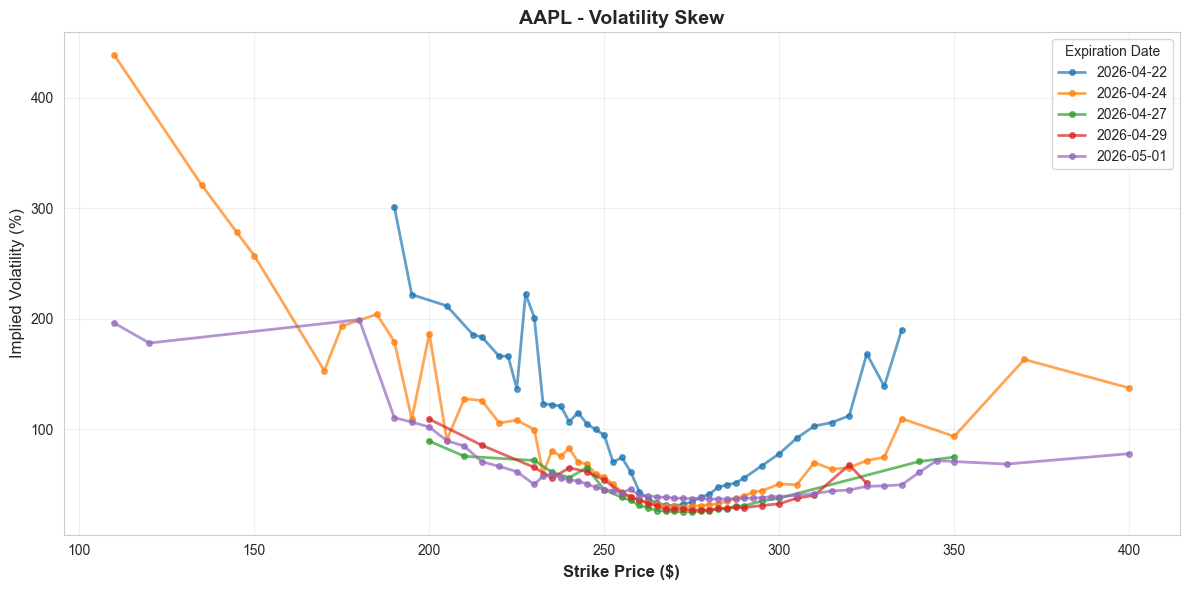

GRAPH 1


In [24]:
fig, ax = plt.subplots(figsize=(12, 6))

unique_exps = sorted(options_df['expiration'].unique())

for exp in unique_exps[:5]:  # limiting so plot doesn't get too messy
    subset = options_df[options_df['expiration'] == exp]
    subset = subset.sort_values('strike')

    ax.plot(subset['strike'], subset['impliedVolatility'] * 100,
            marker='o', label=f'{exp}', alpha=0.7, linewidth=2, markersize=4)

ax.set_xlabel('Strike Price ($)', fontsize=12, fontweight='bold')
ax.set_ylabel('Implied Volatility (%)', fontsize=12)
ax.set_title(f'{ticker} - Volatility Skew', fontsize=14, fontweight='bold')

ax.legend(title='Expiration Date', loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("GRAPH 1")

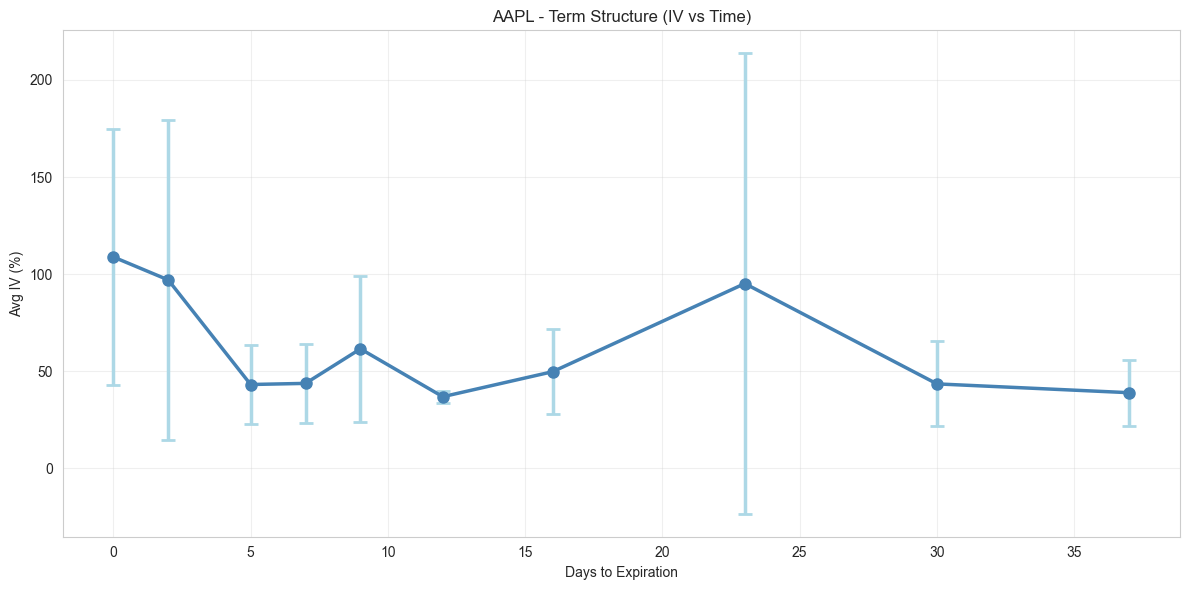

GRAPH 2


In [25]:
iv_by_dte = options_df.groupby('dte')['impliedVolatility'].agg(['mean', 'std'])
iv_by_dte = iv_by_dte.sort_index()

fig, ax = plt.subplots(figsize=(12, 6))

ax.errorbar(iv_by_dte.index, iv_by_dte['mean'] * 100,
            yerr=iv_by_dte['std'] * 100,
            marker='o', linestyle='-', capsize=5, capthick=2,
            linewidth=2.5, markersize=8, color='steelblue', ecolor='lightblue')

ax.set_xlabel('Days to Expiration')
ax.set_ylabel('Avg IV (%)')
ax.set_title(f'{ticker} - Term Structure (IV vs Time)')

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("GRAPH 2")

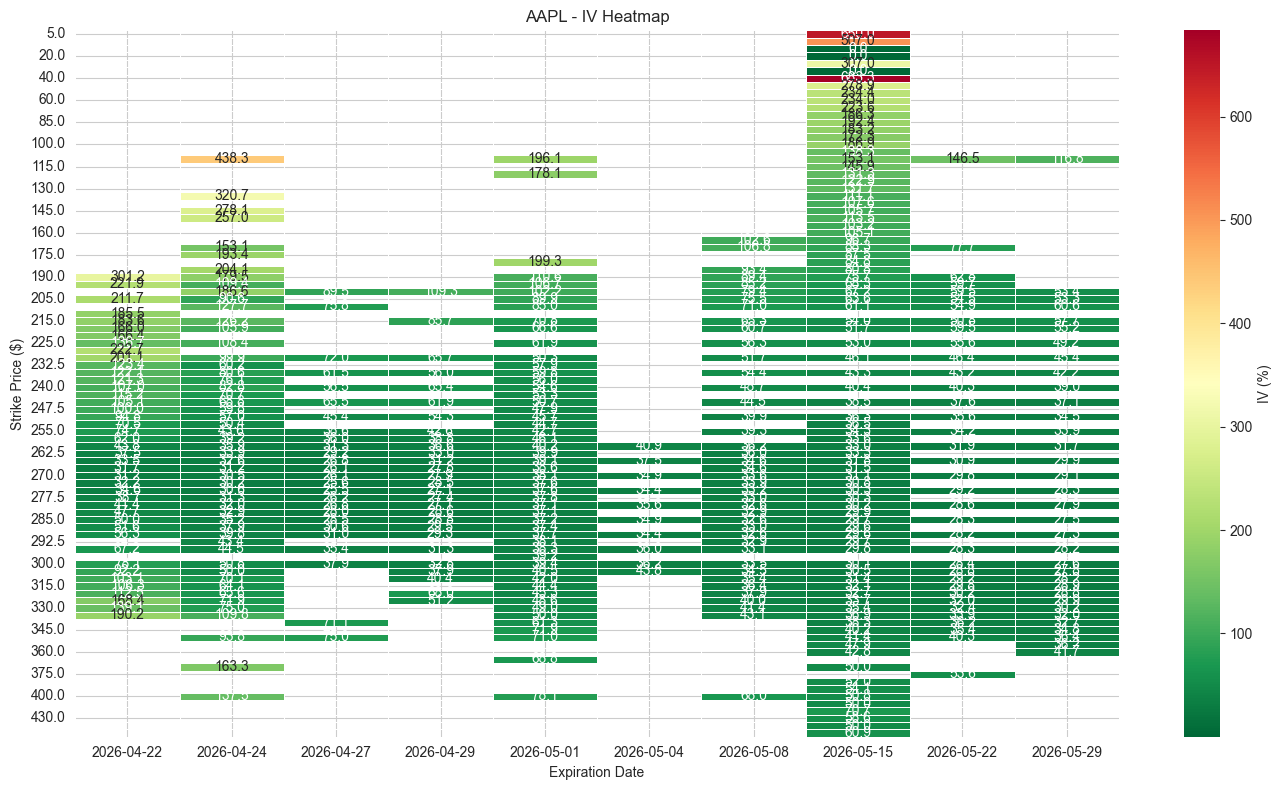

GRAPH 3


In [26]:
pivot_tbl = options_df.pivot_table(values='impliedVolatility',
                                   index='strike',
                                   columns='expiration',
                                   aggfunc='first')

fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(pivot_tbl * 100, cmap='RdYlGn_r', annot=True, fmt='.1f',
            cbar_kws={'label': 'IV (%)'}, ax=ax, linewidths=0.5)

ax.set_title(f'{ticker} - IV Heatmap')
ax.set_ylabel('Strike Price ($)')
ax.set_xlabel('Expiration Date')

plt.tight_layout()
plt.show()

print("GRAPH 3")

In [27]:
print("\n" + "="*60)
print("STATS + QUICK INSIGHTS")
print("="*60)

iv_series = options_df['impliedVolatility']

print("\nOverall IV:")
print(f"Mean: {iv_series.mean():.2%}")
print(f"Median: {iv_series.median():.2%}")
print(f"Std: {iv_series.std():.2%}")
print(f"Min/Max: {iv_series.min():.2%} / {iv_series.max():.2%}")

print("\nTop expirations by IV:")
exp_iv = options_df.groupby('expiration')['impliedVolatility'].mean().sort_values(ascending=False)

for exp, iv in exp_iv.head(5).items():
    dte_val = options_df[options_df['expiration'] == exp]['dte'].iloc[0]
    print(f"{exp} ({dte_val}d): {iv:.2%}")

print("\nLiquidity snapshot:")
print(f"Total OI: {options_df['openInterest'].sum():,.0f}")
print(f"Avg OI: {options_df['openInterest'].mean():.0f}")

# quick skew estimate (kind of rough but good enough)
lower_q = options_df['strike'].quantile(0.4)
upper_q = options_df['strike'].quantile(0.6)

atm_iv = options_df[options_df['strike'].between(lower_q, upper_q)]['impliedVolatility'].mean()
otm_call_iv = options_df[options_df['strike'] > options_df['strike'].quantile(0.7)]['impliedVolatility'].mean()
otm_put_iv = options_df[options_df['strike'] < options_df['strike'].quantile(0.3)]['impliedVolatility'].mean()

print("\nSkew:")
print(f"ATM: {atm_iv:.2%}")
print(f"OTM Calls: {otm_call_iv:.2%}")
print(f"OTM Puts: {otm_put_iv:.2%}")

if otm_put_iv > otm_call_iv:
    print("Downside protection more expensive (normal-ish)")
else:
    print("Upside vols higher than expected")

print("BAM")


STATS + QUICK INSIGHTS

Overall IV:
Mean: 70.52%
Median: 44.47%
Std: 72.65%
Min/Max: 0.00% / 683.35%

Top expirations by IV:
2026-04-22 (0d): 108.83%
2026-04-24 (2d): 97.01%
2026-05-15 (23d): 95.13%
2026-05-01 (9d): 61.50%
2026-05-08 (16d): 49.74%

Liquidity snapshot:
Total OI: 750,500
Avg OI: 1835

Skew:
ATM: 36.86%
OTM Calls: 50.52%
OTM Puts: 130.64%
Downside protection more expensive (normal-ish)
BAM


In [19]:
print("KEY INSIGHTS & INTERPRETATION")
print("="*70)

# --- Volatility Skew (rough approximation) ---
# using quantiles here instead of true ATM — not perfect but good enough for now
low_q = options_df['strike'].quantile(0.4)
high_q = options_df['strike'].quantile(0.6)

atm_slice = options_df[options_df['strike'].between(low_q, high_q)]
atm_iv = atm_slice['impliedVolatility'].mean()

# kinda recomputing quantiles again... could store but leaving it
otm_call_iv = options_df[options_df['strike'] > options_df['strike'].quantile(0.7)]['impliedVolatility'].mean()
otm_put_iv  = options_df[options_df['strike'] < options_df['strike'].quantile(0.3)]['impliedVolatility'].mean()

print("\n1. Volatility Skew:")
print(f"   ATM IV: {atm_iv:.2%}")
print(f"   OTM Calls: {otm_call_iv:.2%}")
print(f"   OTM Puts: {otm_put_iv:.2%}")

if otm_put_iv > otm_call_iv:
    print("    Downside skew (puts richer than calls)")
    print("     Not surprising — market usually prices crash risk heavier")
else:
    print("    Upside skew (calls richer)")
    print("     A bit unusual, might be momentum/speculation driven")


# --- Term Structure ---
# breaking into buckets manually (could make cleaner later)
near_iv = options_df[options_df['dte'] <= 7]['impliedVolatility'].mean()
mid_iv  = options_df[(options_df['dte'] > 7) & (options_df['dte'] <= 30)]['impliedVolatility'].mean()
far_iv  = options_df[options_df['dte'] > 30]['impliedVolatility'].mean()

print("\n2. Term Structure:")
print(f"   Short-term (<=7d): {near_iv:.2%}")
print(f"   Mid-term (8-30d): {mid_iv:.2%}")
print(f"   Long-term (>30d): {far_iv:.2%}")

if far_iv > near_iv:
    print("    Upward sloping curve")
    print("     Suggests market expects more uncertainty later")
else:
    print("    Inverted / downward sloping")
    print("     Usually means near-term event risk is priced in")


# --- Liquidity ---
print("\n3. Liquidity Observations:")

# grouping twice... not super efficient but readable
most_liq_exp = options_df.groupby('expiration')['openInterest'].sum().idxmax()
most_liq_strike = options_df.groupby('strike')['openInterest'].sum().idxmax()

print(f"   Most active expiration: {most_liq_exp}")
print(f"   Most active strike: ${most_liq_strike:.0f}")

# this is kind of a generic statement but usually true
print("    Activity tends to cluster near ATM + front expirations")
print("     (basically where most of the real trading happens)")


print("\n" + "="*70)
print(f"Finished analysis for {ticker}")

KEY INSIGHTS & INTERPRETATION

1. Volatility Skew:
   ATM IV: 36.86%
   OTM Calls: 50.52%
   OTM Puts: 130.64%
    Downside skew (puts richer than calls)
     Not surprising — market usually prices crash risk heavier

2. Term Structure:
   Short-term (<=7d): 81.12%
   Mid-term (8-30d): 68.23%
   Long-term (>30d): 38.93%
    Inverted / downward sloping
     Usually means near-term event risk is priced in

3. Liquidity Observations:
   Most active expiration: 2026-05-15
   Most active strike: $280
    Activity tends to cluster near ATM + front expirations
     (basically where most of the real trading happens)

Finished analysis for AAPL
